### Adaboost Machine Learning

In [298]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [299]:
df = pd.read_csv("Travel.csv")

In [300]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


### Data Cleaning

In [301]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [302]:
# Check all Categories
df["Gender"].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [303]:
df["MaritalStatus"].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [304]:
df["TypeofContact"].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [305]:
df["Passport"].value_counts()

Passport
0    3466
1    1422
Name: count, dtype: int64

In [306]:
df["Gender"] = df["Gender"].replace("Fe Male", "Female")
df["MaritalStatus"] = df["MaritalStatus"].replace("Single", "Unmarried")

In [307]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [308]:
# Check Missing Values
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [309]:
features_with_nan = [features for features in df.columns if df[features].isnull().sum() >= 1]

for feature in features_with_nan :
    print(feature, np.round(df[feature].isnull().mean()*100, 5), "% missing values")

Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


In [310]:
# Statistics on numerical columns (Null columns)
df[features_with_nan].select_dtypes(exclude="object").describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [311]:
# Imputing Null values

# Age
df.Age.fillna(df.Age.median(), inplace=True)

# TypeofContract
df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace=True)

# DurationofPitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace=True)

# NumberofFollowup
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace=True)

# PreferredPropertyStar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace=True)

# NumberofTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace=True)

# NumberofChildrenVisiting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace=True)

# MonthlyIncome
df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace=True)

In [312]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [313]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [314]:
df.drop("CustomerID", inplace=True, axis=1)

### Feature Engineering

In [315]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [316]:
# Create new column for features
df["TotalVisitors"] = df.NumberOfPersonVisiting + df.NumberOfChildrenVisiting
df.drop(["NumberOfChildrenVisiting", "NumberOfPersonVisiting"], inplace=True, axis=1)

In [317]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisitors
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [318]:
# Get all the numerical features
num_features = [feature for feature in df.columns if df[feature].dtype != "O"]
print(f"No. of Numerical features : {len(num_features)}")

No. of Numerical features : 12


In [319]:
# Get all categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == "O"]
print(f"No. of Categorical features : {len(cat_features)}")

No. of Categorical features : 6


In [320]:
# Discrete features
disc_features = [feature for feature in num_features if len(df[feature].unique()) <= 25]
print(f"No. of Discrete features : {len(disc_features)}")

No. of Discrete features : 9


In [321]:
# Discrete features
cont_features = [feature for feature in num_features if len(df[feature].unique()) >= 25]
print(f"No. of Continous features : {len(cont_features)}")

No. of Continous features : 3


In [322]:
# Train test split
X = df.drop(["ProdTaken"], axis=1)
y = df["ProdTaken"]

In [323]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [324]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisitors
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [325]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: ProdTaken, dtype: int64

In [326]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [327]:
X_train.shape, X_test.shape

((3910, 17), (978, 17))

In [328]:
# Create Column Transformer with 3 types of transformers
cat_features = X.select_dtypes(include="object").columns
num_features = X.select_dtypes(exclude="object").columns

numeric_tranformer = StandardScaler()
oh_transformer = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer (
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_tranformer, num_features)
    ]
)

In [329]:
X_train = preprocessor.fit_transform(X_train)

In [330]:
pd.DataFrame(X_train) #type: ignore

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,-0.157926,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.508072,-0.721400,0.690023,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.396069,-0.721400,-1.020350,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.064073,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.730071,-0.721400,2.400396,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,-1.045924,-0.721400,-0.653841,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.397072,1.455047,-0.898180,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.064073,1.455047,1.545210,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-1.045924,1.455047,1.789549,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,-0.252799,0.643615


In [331]:
X_test = preprocessor.transform(X_test)

In [332]:
pd.DataFrame(X_test) #type: ignore

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.601925,1.455047,-0.287333,1.284279,-0.725271,-1.220627,-0.632399,-0.777720,-1.277194,-0.737510,-0.774151
1,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.952071,0.366823,-0.531672,0.282777,0.522885,-1.220627,1.581280,1.408395,-1.277194,-0.670411,-0.065268
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.046926,1.455047,0.812193,0.282777,-0.725271,0.965153,-0.632399,1.408395,0.782966,-0.420832,-0.774151
3,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.619072,-0.721400,2.522566,2.285781,-0.725271,1.511598,-0.632399,-0.049015,0.782966,-0.113658,0.643615
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,-1.378923,1.455047,-1.020350,0.282777,0.522885,-0.127737,1.581280,0.679690,0.782966,-0.317047,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.064073,-0.721400,-1.020350,0.282777,-0.725271,1.511598,-0.632399,1.408395,0.782966,0.498219,0.643615
974,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.934924,-0.721400,-1.142519,0.282777,1.771041,-0.674182,1.581280,-1.506426,-1.277194,-1.184015,-1.483035
975,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.268926,-0.721400,1.056532,1.284279,-0.725271,-0.674182,1.581280,1.408395,0.782966,0.690012,0.643615
976,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.267923,-0.721400,-0.287333,-2.721728,-0.725271,-0.674182,-0.632399,1.408395,0.782966,-0.228278,-0.774151


In [333]:
models = {
    "Adaboost Classification" : AdaBoostClassifier(),
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
}

for i in range(len(list(models))) :
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    
    # Make Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average="weighted")
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_racauc_score = roc_auc_score(y_train, y_train_pred)
    
    # Test set performanc
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average="weighted")
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_racauc_score = roc_auc_score(y_test, y_test_pred)
    
    
    print(list(models.keys())[i])
    
    print(f"----Model Performace for Training set----")
    print(f"Accuracy : {round(model_train_accuracy, 3)}")
    print(f"F1 score : {round(model_train_f1, 3)}") #type: ignore
    print(f"Precision : {round(model_train_precision, 3)}") #type: ignore
    print(f"Recall score : {round(model_train_recall, 3)}") #type: ignore
    print(f"Roc Auc score : {round(model_train_racauc_score, 3)}")
    
    
    print(f"----Model Performace for Test set----")
    print(f"Accuracy : {round(model_test_accuracy, 3)}")
    print(f"F1 score : {round(model_test_f1, 3)}") #type: ignore
    print(f"Precision : {round(model_test_precision, 3)}") #type: ignore
    print(f"Recall score : {round(model_test_recall, 3)}") #type: ignore
    print(f"Roc Auc score : {round(model_test_racauc_score, 3)}")
    
    print("=" * 49)
    print("\n")

Adaboost Classification
----Model Performace for Training set----
Accuracy : 0.848
F1 score : 0.815
Precision : 0.782
Recall score : 0.255
Roc Auc score : 0.619
----Model Performace for Test set----
Accuracy : 0.835
F1 score : 0.799
Precision : 0.75
Recall score : 0.236
Roc Auc score : 0.608


Logistic Regression
----Model Performace for Training set----
Accuracy : 0.846
F1 score : 0.82
Precision : 0.702
Recall score : 0.303
Roc Auc score : 0.637
----Model Performace for Test set----
Accuracy : 0.836
F1 score : 0.809
Precision : 0.691
Recall score : 0.293
Roc Auc score : 0.631


Decision Tree
----Model Performace for Training set----
Accuracy : 1.0
F1 score : 1.0
Precision : 1.0
Recall score : 1.0
Roc Auc score : 1.0
----Model Performace for Test set----
Accuracy : 0.919
F1 score : 0.919
Precision : 0.804
Recall score : 0.775
Roc Auc score : 0.865


Random Forest
----Model Performace for Training set----
Accuracy : 1.0
F1 score : 1.0
Precision : 1.0
Recall score : 1.0
Roc Auc score : 1

### Hyperparameter Tuning

In [ ]:
ad_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1],
}

rf_params = {
    "max_depth": [5, 8, 10, 15, None],
    "max_features": ["sqrt", "log2", None],
    "min_samples_split": [2, 8, 15, 20],
    "n_estimators": [100, 200, 300, 500, 1000]
}

In [ ]:
# Models list for Hyperparameter tuning
randomcv_models = [
    ("Adaboost", AdaBoostClassifier(), ad_params),
    ("RF", RandomForestClassifier(), rf_params)

]

In [336]:
model_params = {}

for name, model, params in randomcv_models :
    random = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=100, cv=3, verbose=2, n_jobs=-1, error_score="raise")
    
    random.fit(X_train, y_train)
    model_params[name] = random.best_params_
    
for model_name in model_params :
    print(f"------------------- Best Params for {model_name} ---------------------------")
    print(model_params[model_name])

Fitting 3 folds for each of 9 candidates, totalling 27 fits


c:\Users\Aadarsh\Desktop\CODE\venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=100. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 100 candidates, totalling 300 fits
------------------- Best Params for Adaboost ---------------------------
{'n_estimators': 100, 'learning_rate': 1}
------------------- Best Params for RF ---------------------------
{'n_estimators': 1000, 'min_samples_split': 2, 'max_features': None, 'max_depth': None}


In [337]:
models = {
    "Adaboost Classifier" : AdaBoostClassifier(n_estimators=100, learning_rate=1), #type: ignore
    "Random Forest Classifier" : RandomForestClassifier(n_estimators=300, min_samples_split=2, max_features=None, max_depth=None) #type: ignore
}

for i in range(len(list(models))) :
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    
    # Make Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average="weighted")
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_racauc_score = roc_auc_score(y_train, y_train_pred)
    
    # Test set performanc
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average="weighted")
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_racauc_score = roc_auc_score(y_test, y_test_pred)
    
    
    print(list(models.keys())[i])
    
    print(f"----Model Performace for Training set----")
    print(f"Accuracy : {round(model_train_accuracy, 3)}")
    print(f"F1 score : {round(model_train_f1, 3)}") #type: ignore
    print(f"Precision : {round(model_train_precision, 3)}") #type: ignore
    print(f"Recall score : {round(model_train_recall, 3)}") #type: ignore
    print(f"Roc Auc score : {round(model_train_racauc_score, 3)}")
    
    
    print(f"----Model Performace for Test set----")
    print(f"Accuracy : {round(model_test_accuracy, 3)}")
    print(f"F1 score : {round(model_test_f1, 3)}") #type: ignore
    print(f"Precision : {round(model_test_precision, 3)}") #type: ignore
    print(f"Recall score : {round(model_test_recall, 3)}") #type: ignore
    print(f"Roc Auc score : {round(model_test_racauc_score, 3)}")
    
    print("=" * 49)
    print("\n")

Adaboost Classifier
----Model Performace for Training set----
Accuracy : 0.848
F1 score : 0.816
Precision : 0.774
Recall score : 0.263
Roc Auc score : 0.623
----Model Performace for Test set----
Accuracy : 0.838
F1 score : 0.801
Precision : 0.789
Recall score : 0.236
Roc Auc score : 0.61


Random Forest Classifier
----Model Performace for Training set----
Accuracy : 1.0
F1 score : 1.0
Precision : 1.0
Recall score : 1.0
Roc Auc score : 1.0
----Model Performace for Test set----
Accuracy : 0.949
F1 score : 0.947
Precision : 0.961
Recall score : 0.77
Roc Auc score : 0.881




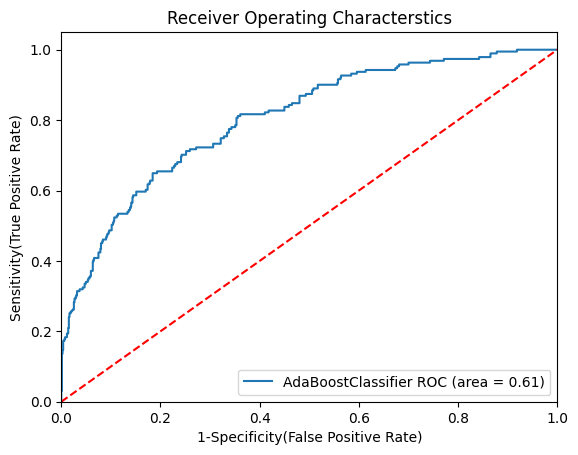

In [338]:
# Plot ROC AUC Curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
    {
        "label" : "AdaBoostClassifier", 
        "model" : AdaBoostClassifier(n_estimators=100, learning_rate=1), #type: ignore
        "auc" : 0.61
    }
]

# Create loop through all model
for algo in auc_models :
    model = algo["model"]
    model.fit(X_train, y_train)
    
    # Compute False positive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    
    # Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label="%s ROC (area = %0.2f)" % (algo["label"], algo["auc"]))
    
# Customize settings for the plot
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("1-Specificity(False Positive Rate)")
plt.ylabel("Sensitivity(True Positive Rate)")
plt.title("Receiver Operating Characterstics")
plt.legend(loc="lower right")
plt.savefig("Auc.png")
plt.show()